cp: cannot stat 'kaggle.json': No such file or directory


403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


Saving kaggle.json to kaggle.json


ref                           title                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------  ------------------  ----------  --------------------------  -------------  ---------  ---------------  
salader/dogsvscats            dogsVScats          1142791694  2018-11-30 16:21:15.747000          16254        167  0.375            
pandurangjadhav/dogsvscats    DogsvsCats           856552595  2022-04-24 10:55:02.360000             71          3  0.3125           
jvernughanan/dogsvscats       dogsvscats           812888725  2025-09-12 09:30:48.757000              2          1  0.125            
thomasyk/checkpoint           dogsvscats            12102027  2022-11-06 01:34:28.883000             19          0  0.25             
johnorwell/dogsvscatscsj      dogsVScatsCSJ        570880858  2020-05-30 11:37:37.207000             10          1  0.1875           
anhnguyenluuhong/dogsvscats   dogsvscats            55962127  

In [ ]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:05<00:00, 203MB/s]



In [ ]:
!mkdir -p dogsvscats

In [ ]:
!unzip -q dogsvscats.zip -d dogsvscats

In [ ]:
import os

print("Dataset:", os.listdir("dogsvscats"))

print("Train:", os.listdir("dogsvscats/train"))
print("Test:", os.listdir("dogsvscats/test"))

Dataset: ['train', 'catsvsdogs', 'test']
Train: ['cats', 'dogs']
Test: ['cats', 'dogs']


In [ ]:
# install required libraries

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.layers import BatchNormalization,Dropout


In [ ]:
# generator

train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogsvscats/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)



)

validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogsvscats/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)



)



Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
# first normalize numpy data image to
# small scale

def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label


train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)




In [ ]:
# create CNN model
# 3 convolution layer



model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 94ms/step - accuracy: 0.5764 - loss: 1.3833 - val_accuracy: 0.6568 - val_loss: 0.6253
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.6912 - loss: 0.5882 - val_accuracy: 0.6670 - val_loss: 0.6551
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7484 - loss: 0.5174 - val_accuracy: 0.7018 - val_loss: 0.5994
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7960 - loss: 0.4352 - val_accuracy: 0.7764 - val_loss: 0.4575
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8335 - loss: 0.3682 - val_accuracy: 0.7898 - val_loss: 0.5108
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.8676 - loss: 0.3066 - val_accuracy: 0.8096 - val_loss: 0.4615
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.9011 - loss: 0.2377 - val_accuracy: 0.7866 - val_loss: 0.6803
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9331 - loss: 0.1667 - 

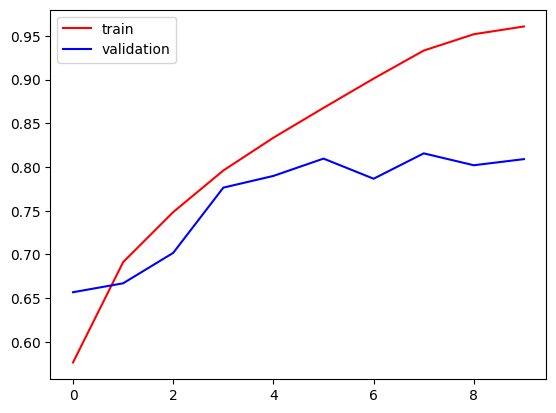

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

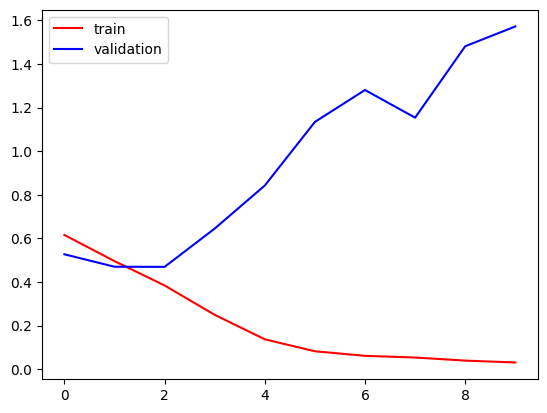

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

#overfiting creation



In [ ]:
# way to reduce overfiting

# add more data
# data augmentation
# l1/l2 regularization
# dropout
# batch norm
# reduce complexity

In [ ]:
import cv2

In [ ]:
# new unsean data test for cat
test_cat=cv2.imread('/content/dogsvscats/catsvsdogs/test_cat.jpg')

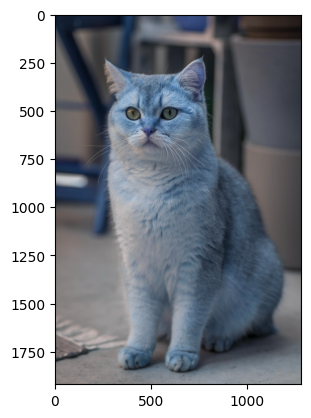

In [ ]:
plt.imshow(test_cat)

In [ ]:
test_cat.shape  #first reshape this image
# because your model 256,256 train

(1920, 1280, 3)

In [ ]:
test_cat=cv2.resize(test_cat,(256,256))

In [ ]:
test_catinput=test_cat.reshape(1,256,256,3)  #four dimention because our dataset is that type

In [ ]:
model.predict(test_catinput)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[0.]], dtype=float32)

In [ ]:
# same as new dog image
test_dog=cv2.imread('/content/dogsvscats/catsvsdogs/dog1.jpg')

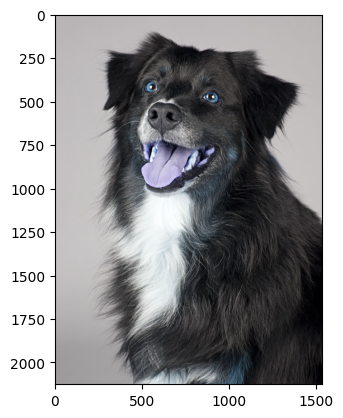

In [ ]:
plt.imshow(test_dog)

In [ ]:
test_dog.shape
test_dog=cv2.resize(test_dog,(256,256))

In [ ]:
test_doginput=test_dog.reshape(1,256,256,3)

In [ ]:
model.predict(test_doginput)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)